In [16]:
from skimage import io
from skimage.util import img_as_ubyte
import matplotlib.pyplot as plt
import numpy as np
import glob
from sklearn.decomposition import PCA
from skimage.transform import SimilarityTransform
from skimage.transform import warp
import os
import pathlib

In [41]:
def create_u_byte_image_from_vector(im_vec, height, width, channels):
    min_val = im_vec.min()
    max_val = im_vec.max()

    # Transform to [0, 1]
    im_vec = np.subtract(im_vec, min_val)
    im_vec = np.divide(im_vec, max_val - min_val)
    im_vec = im_vec.reshape(height, width, channels)
    im_out = img_as_ubyte(im_vec)
    return im_out

In [42]:
all_images = glob.glob("../training_data/preprocessed/*.jpg")
path = os.path.splitext(all_images[0])[0]
exp_img = io.imread(f"{path}.jpg")
print(exp_img.shape)
n_features = exp_img.shape[0] * exp_img.shape[1] * 3
n_samples = len(all_images)
print(n_features, n_samples)

(360, 360, 3)
388800 100


In [43]:
data_matrix = np.zeros((n_samples, n_features))

In [44]:
for i in range(n_samples):
    name_no_ext = os.path.splitext(all_images[i])[0]
    src_img = io.imread(f"{name_no_ext}.jpg")
    data_matrix[i, :] = src_img.flatten()

In [45]:
print(data_matrix)

[[187. 173. 162. ... 246. 254. 255.]
 [  0.   0.   0. ...   0.   0.   0.]
 [  0.   0.   4. ...  82.  87.  83.]
 ...
 [  0.   0.   0. ...   0.   0.   0.]
 [  5.   0.   0. ...  69.  72.  63.]
 [  0.   0.   0. ...   0.   0.   0.]]


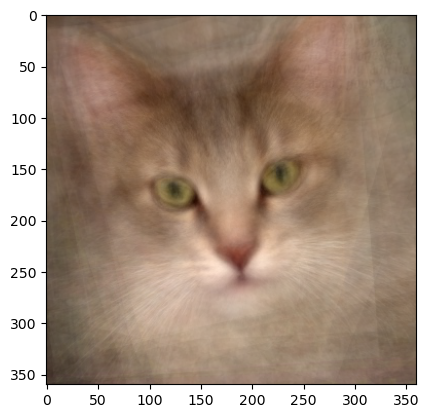

In [48]:
mean_cat = np.mean(data_matrix, axis=0)
mean_cat_img = create_u_byte_image_from_vector(mean_cat, exp_img.shape[1], exp_img.shape[0], 3)
plt.imshow(mean_cat_img)

In [51]:
missing_cat = io.imread("../data/MissingCatProcessed.jpg")
print(missing_cat.shape)
missing_img_flatten = missing_cat.flatten()

(360, 360, 3)


In [54]:
sub_data = data_matrix - missing_img_flatten
sub_distances = np.linalg.norm(sub_data, axis=1)
min_idx = np.argmin(sub_distances)
print(min_idx)

88


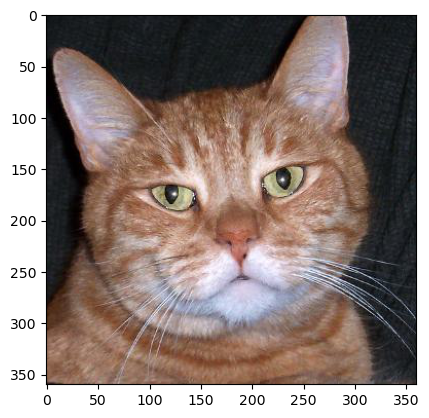

In [56]:
replacement_cat_img = create_u_byte_image_from_vector(data_matrix[min_idx,:], exp_img.shape[1], exp_img.shape[0], 3)
plt.imshow(replacement_cat_img)

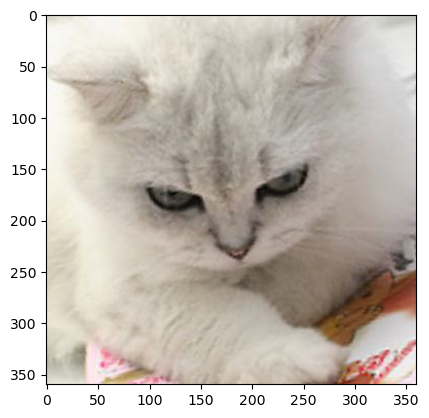

In [58]:
max_idx = np.argmax(sub_distances)
bad_fitting_cat = create_u_byte_image_from_vector(data_matrix[max_idx,:], exp_img.shape[1], exp_img.shape[0], 3)
plt.imshow(bad_fitting_cat)

In [59]:
print("Computing PCA")
cats_pca = PCA(n_components=50)
cats_pca.fit(data_matrix)

Computing PCA


,n_components,50
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


Text(0, 0.5, 'Total variation by this component')

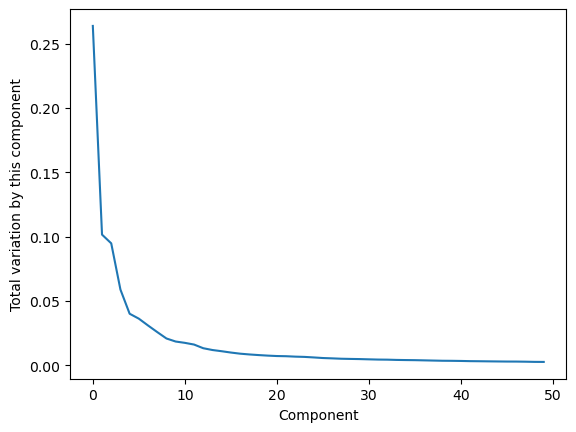

In [62]:
plt.plot(np.arange(50), cats_pca.explained_variance_ratio_)
plt.xlabel("Component")
plt.ylabel("Total variation by this component")

In [63]:
print(cats_pca.explained_variance_ratio_[0])

0.2638454470771584


In [65]:
components = cats_pca.transform(data_matrix)
print(components.shape)

(100, 50)


Text(0, 0.5, 'PC 2')

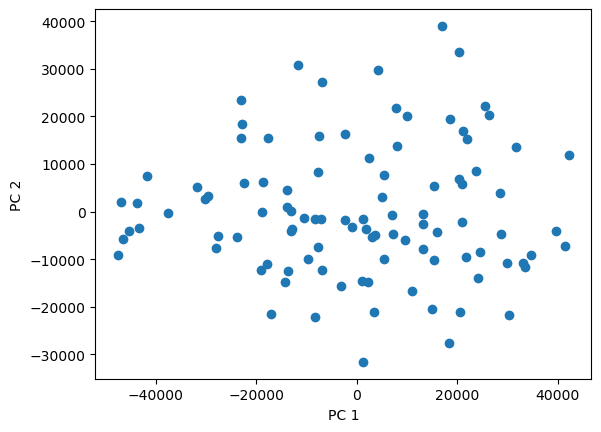

In [ ]:
pc_1 = components[:,0]
pc_2 = components[:,1]
plt.scatter(pc_1, pc_2)
plt.xlabel("PC 1")
plt.ylabel("PC 2")

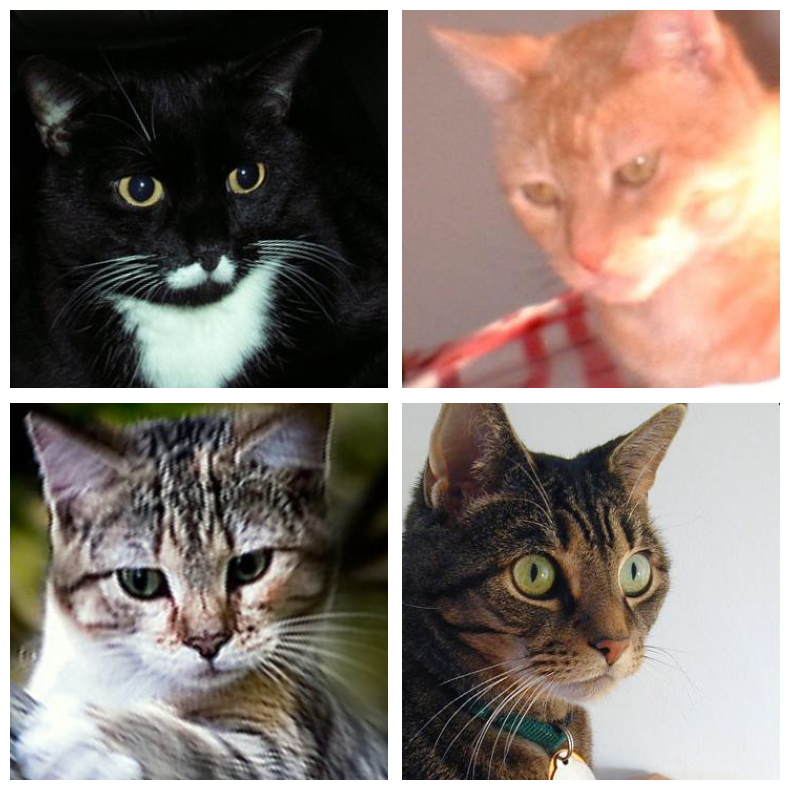

In [73]:
extreme_cats = [np.argmin(pc_1), np.argmax(pc_1), np.argmin(pc_2), np.argmax(pc_2)]
# Create 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
# Flatten axes array for easy indexing
axes = axes.ravel()
for i in range(4):
    axes[i].imshow(create_u_byte_image_from_vector(data_matrix[extreme_cats[i],:], exp_img.shape[1], exp_img.shape[0], 3))
    axes[i].axis("off")
    
plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(359.5), np.float64(359.5), np.float64(-0.5))

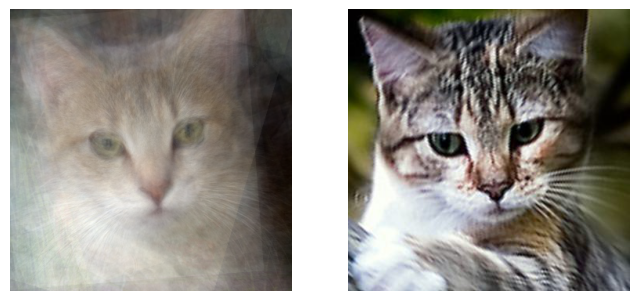

In [91]:
idx = 20
w1, w2 = pc_1[idx], pc_2[idx]
synth_cat = mean_cat + w1 * cats_pca.components_[idx, :] + w2 * cats_pca.components_[1,:]
fig, axes = plt.subplots(1, 2, figsize=(8, 8))
axes = axes.ravel()
axes[0].imshow(create_u_byte_image_from_vector(synth_cat, exp_img.shape[1], exp_img.shape[0], 3))
axes[0].axis("off")
axes[1].imshow(create_u_byte_image_from_vector(data_matrix[idx,:], exp_img.shape[1], exp_img.shape[0], 3))
axes[1].axis("off")

(np.float64(-0.5), np.float64(359.5), np.float64(359.5), np.float64(-0.5))

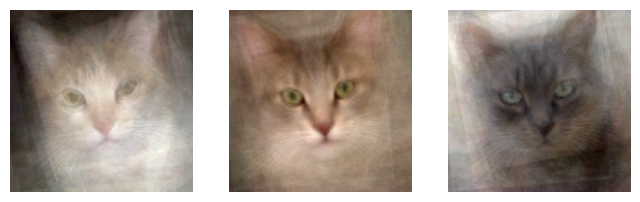

In [99]:
m= 2
synth_cat_plus = mean_cat + 3 * np.sqrt(cats_pca.explained_variance_[m]) * cats_pca.components_[m, :]
synth_cat_minus = mean_cat - 3 * np.sqrt(cats_pca.explained_variance_[m]) * cats_pca.components_[m, :]
fig, axes = plt.subplots(1, 3, figsize=(8, 8))
axes = axes.ravel()
axes[0].imshow(create_u_byte_image_from_vector(synth_cat_minus, exp_img.shape[1], exp_img.shape[0], 3))
axes[0].axis("off")
axes[1].imshow(create_u_byte_image_from_vector(mean_cat, exp_img.shape[1], exp_img.shape[0], 3))
axes[1].axis("off")
axes[2].imshow(create_u_byte_image_from_vector(synth_cat_plus, exp_img.shape[1], exp_img.shape[0], 3))
axes[2].axis("off")

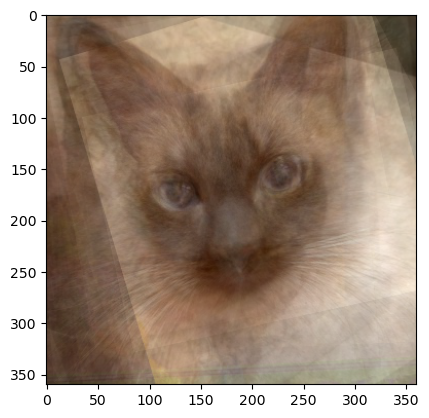

In [100]:
n_components_to_use = 10
synth_cat = mean_cat
for idx in range(n_components_to_use):
	w = np.random.uniform(-1, 1) * 3 * np.sqrt(cats_pca.explained_variance_[idx])
	synth_cat = synth_cat + w * cats_pca.components_[idx, :]
 
plt.imshow(create_u_byte_image_from_vector(synth_cat, exp_img.shape[1], exp_img.shape[0], 3))


In [102]:
im_miss = io.imread("../data/MissingCatProcessed.jpg")
im_miss_flat = im_miss.flatten()
im_miss_flat = im_miss_flat.reshape(1, -1)
pca_coords = cats_pca.transform(im_miss_flat)
pca_coords = pca_coords.flatten()

In [106]:
print(pca_coords.shape)
print(pca_coords[0])

(50,)
-4673.1380871728325


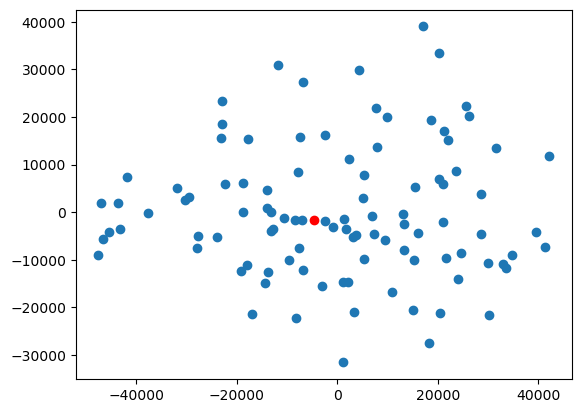

In [108]:
plt.scatter(pc_1, pc_2)
plt.scatter(pca_coords[0], pca_coords[1], color='r')

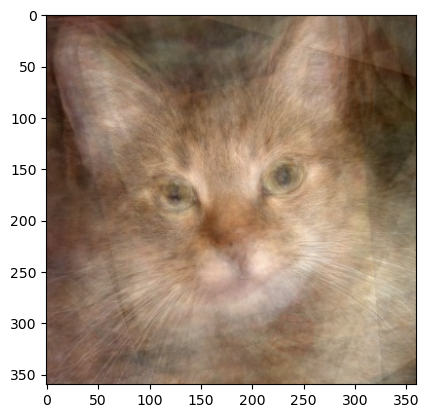

In [111]:
n_components_to_use = 50
synth_cat = mean_cat
for idx in range(n_components_to_use):
	synth_cat = synth_cat + pca_coords[idx] * cats_pca.components_[idx, :]
 
plt.imshow(create_u_byte_image_from_vector(synth_cat, exp_img.shape[0], exp_img.shape[1], 3))

In [115]:
comp_sub = components - pca_coords
pca_distances = np.linalg.norm(comp_sub, axis=1)
print(pca_distances)

[45877.1443571  37047.09243404 50502.44143409 47354.52650464
 40450.23892553 55921.84233694 47650.597137   42364.90694627
 54732.32498072 41476.85194893 55496.03363015 48829.00001263
 64809.7490013  43979.37469419 37330.63170199 41721.31307598
 49693.24110921 50677.77803692 53663.75718616 48614.82891114
 44492.48921404 50098.77870778 58745.35760071 52469.5867665
 56365.95486882 30266.81138499 54014.1670454  31636.26239962
 27919.77500952 63607.08755393 42466.60747583 49804.37770301
 57451.7105514  47644.57034742 46338.63591649 37626.64915659
 43048.8055542  39566.86563383 38963.36971233 64825.65780701
 52357.61183211 42426.83553432 50091.52339912 35681.33533738
 48161.08685813 30132.11083342 51311.23810067 37020.06999021
 58866.72606846 39764.27301035 51838.66548275 49994.90763191
 57884.26333833 46797.67555613 34388.72329813 34739.37092051
 52477.07485957 44447.77714477 58656.40072664 38037.03396278
 48567.2270913  38264.6110154  53692.58902444 35419.30205409
 29126.59772587 54672.092

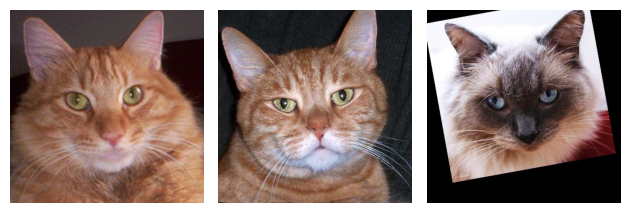

In [121]:
fig, ax = plt.subplots(1,3)
ax.ravel()
ax[0].imshow(create_u_byte_image_from_vector(im_miss_flat, exp_img.shape[1], exp_img.shape[0], 3))
ax[0].axis("off")
ax[1].imshow(create_u_byte_image_from_vector(data_matrix[np.argmin(pca_distances),:], exp_img.shape[1], exp_img.shape[0], 3))
ax[1].axis("off")
ax[2].imshow(create_u_byte_image_from_vector(data_matrix[np.argmax(pca_distances),:], exp_img.shape[1], exp_img.shape[0], 3))
ax[2].axis("off")
fig.tight_layout()
plt.show()